<h1><font color="#113D68" size=5>Redes neuronales y deep learning</font></h1>



<h1><font color="#113D68" size=6>Actividad Semana 2</font></h1>


<br><br>
<div style="text-align: right">
<font size=3>Daniel González</font><br>
<font size=3>Semana 2: Frameworks de Deep Learning: TensorFlow</font><br>
<font size=3>IEBS</font>
</div>

---


In [2]:
import tensorflow as tf
import numpy as np

# Para mostrar gráficas
import matplotlib.pyplot as plt
%matplotlib inline

# Anaconda fixing problem
# import os
# os.environ['KMP_DUPLICATE_LIB_OK']='True' #Esta no es la solución optima, pero es la más rápida para evitar el error de duplicación de librerías de Anaconda
# En el propio mensaje de error indica que esta no es la mejor solución, puede arreglarse buscando la ubicación del fichero y eliminando la duplicación de librerías.
# Hecho

En esta actividad vamos a seguir familiarizándonos con la herramienta *TensorFlow*, para ello vamos a utilizar un dataset donde tendréis que relizar todos los pasos (cargar datos, crear arquitectura de la red, etc.) vosotros mismos para prácticar con la sintásis de *TensorFlow*. Tendéis ejercicios obligatorio y un ejercicio opcional.

# <font color="#004D7F" size=5>Ejercicio</font>
Usando los datos visto en los ejercicios sobre casa y sus precios realiza los ejercicios que se indican.

La información de los datos podéis verla en este enlace:

https://www.tensorflow.org/api_docs/python/tf/keras/datasets/boston_housing/load_data

## <font color="#004D7F" size=4>Ejercicio 1</font>
Carga los datos como hemos visto en el notebook de los ejercicios donde tengas los conjuntos de train y test:

In [3]:
# Cargamos los datos de Boston Housing

(train_data, train_targets), (test_data, test_targets) = tf.keras.datasets.boston_housing.load_data()

57344/57026 [==============================] - 0s 0us/step


Explora los tamaños de cada conjunto:

In [4]:
# Comprobamos el shape de los datos
print("train_data shape: ", train_data.shape)
print("train_targets shape: ", train_targets.shape)
print("test_data shape: ", test_data.shape)
print("test_targets shape: ", test_targets.shape)


train_data shape:  (404, 13)
train_targets shape:  (404,)
test_data shape:  (102, 13)
test_targets shape:  (102,)


## <font color="#004D7F" size=4>Ejercicio 2</font>
Crear una red con la siguiente configuración y entrénala:

- **Configuración de la red**:
    - Arquitectura de la red:
        - *1º Capa*: capa de entrada donde indiques la dimensión de los datos.
        - *2º Capa*: capa densa con 8 neuronas y función de activación *relu*.
        - *3º Capa*: capa densa con 8 neuronas y función de activación *relu*.
        - *4º Capa*: capa de salida con una neurona sin función de activación.
    - Tipo de entrenamiento:
        - *Epochs*: 100
        - *Optimizador*: *adam*
        - *Learning Rate*: 0.001
        - *Función de error*: error cuadrático medio (*mean_squared_error*)

In [49]:
# Importamos las capas que vamos a necesitar
from tensorflow.keras.layers import Dense, InputLayer

# Importamos las métricas que vamos a utilizar
from tensorflow.keras.metrics import MeanAbsoluteError, MeanSquaredError

# Creamos la arquitectura del modelo

model = tf.keras.Sequential()

model.add(InputLayer(input_shape=(train_data.shape[1],)))
model.add(Dense(8, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation=None))

# Definimos el optimizador
opt = tf.keras.optimizers.Adam(learning_rate=0.001)

# Compilamos el modelo
model.compile(optimizer= opt, loss='mse', metrics=['mae'])

print(model.summary())


Model: "sequential_12"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_28 (Dense)             (None, 8)                 112       
_________________________________________________________________
dense_29 (Dense)             (None, 8)                 72        
_________________________________________________________________
dense_30 (Dense)             (None, 1)                 9         
Total params: 193
Trainable params: 193
Non-trainable params: 0
_________________________________________________________________
None


In [50]:
history = model.fit(train_data, train_targets, epochs=100, validation_split=0.2, batch_size=32, verbose=1)

Epoch 1/100
11/11 [==============================] - 0s 5ms/step - loss: 5654.9541 - mae: 72.9199 - val_loss: 3719.2520 - val_mae: 59.5352
Epoch 2/100
11/11 [==============================] - 0s 787us/step - loss: 2241.6060 - mae: 44.7767 - val_loss: 1256.5460 - val_mae: 33.2100
Epoch 3/100
11/11 [==============================] - 0s 767us/step - loss: 609.5219 - mae: 20.8537 - val_loss: 302.6971 - val_mae: 13.4331
Epoch 4/100
11/11 [==============================] - 0s 747us/step - loss: 167.2399 - mae: 9.4240 - val_loss: 148.6682 - val_mae: 9.0229
Epoch 5/100
11/11 [==============================] - 0s 767us/step - loss: 144.0191 - mae: 9.3035 - val_loss: 143.4427 - val_mae: 9.1898
Epoch 6/100
11/11 [==============================] - 0s 789us/step - loss: 139.3103 - mae: 9.1519 - val_loss: 130.0469 - val_mae: 8.4181
Epoch 7/100
11/11 [==============================] - 0s 777us/step - loss: 117.8943 - mae: 8.1038 - val_loss: 127.0006 - val_mae: 7.9643
Epoch 8/100
11/11 [==============

Evalúa el modelo usando la función *evaluate* para el conjunto de test:

4/4 [==============================] - 0s 333us/step - loss: 74.1014 - mae: 6.4681
Resultados del modelo
Pérdida:  74.10135650634766
MAE:  6.468131065368652
Gráfica de evolución del entrenamiento


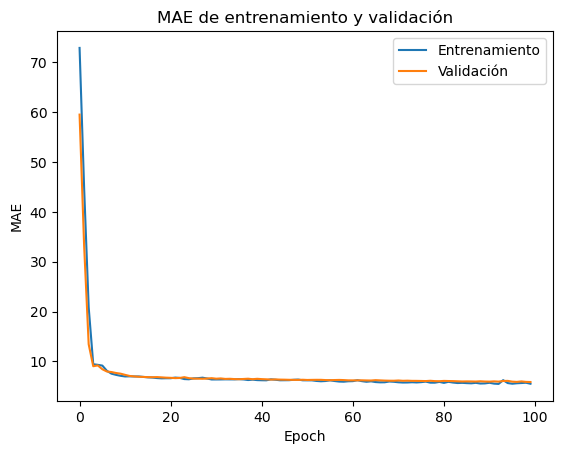

4/4 [==============================] - 0s 383us/step - loss: 74.1014 - mae: 6.4681


In [51]:
# Vamos a evaluar el modelo
resultado = model.evaluate(test_data, test_targets, verbose=1)
print('Resultados del modelo')
print('Pérdida: ', resultado[0])
print('MAE: ', resultado[1])

# Representamos los resultados en una gráfica
print('Gráfica de evolución del entrenamiento')
plt.plot(history.history['mae'])
plt.plot(history.history['val_mae'])
plt.title('MAE de entrenamiento y validación')
plt.ylabel('MAE')
plt.xlabel('Epoch')
plt.legend(['Entrenamiento', 'Validación'], loc='upper right')
plt.show()


# Vamos a evaluar el modelo
resultado = model.evaluate(test_data, test_targets, verbose=1)


## <font color="#004D7F" size=4>Ejercicio 3</font>
Crear una red con la siguiente configuración y entrénala:

- **Configuración de la red**:
    - Arquitectura de la red:
        - *1º Capa*: capa de entrada donde indiques la dimensión de los datos.
        - *2º Capa*: capa densa con 16 neuronas y función de activación *relu*.
        - *3º Capa*: capa densa con 16 neuronas y función de activación *relu*.
        - *4º Capa*: capa densa con 32 neuronas y función de activación *relu*.
        - *4º Capa*: capa de salida con una neurona sin función de activación.   
    - Tipo de entrenamiento:
        - *Epochs*: 300
        - *Optimizador*: *adam*
        - *Learning Rate*: 0.0001
        - *Función de error*: error cuadrático medio (*mean_squared_error*)

In [46]:
# Establecemos la arquitectura del modelo

model2 = tf.keras.Sequential()
model2.add(InputLayer(input_shape=(train_data.shape[1],)))
model2.add(Dense(16, activation='relu'))
model2.add(Dense(16, activation='relu'))
model2.add(Dense(32, activation='relu'))
model2.add(Dense(1, activation=None))

print(model2.summary())

Model: "sequential_11"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_24 (Dense)             (None, 16)                224       
_________________________________________________________________
dense_25 (Dense)             (None, 16)                272       
_________________________________________________________________
dense_26 (Dense)             (None, 32)                544       
_________________________________________________________________
dense_27 (Dense)             (None, 1)                 33        
Total params: 1,073
Trainable params: 1,073
Non-trainable params: 0
_________________________________________________________________
None


In [47]:
# Definimos el optimizador
opt = tf.keras.optimizers.Adam(learning_rate=0.0001)

# Entrenamos el modelo
model2.compile(optimizer='adam', loss='mse', metrics=['mae'])
history2 = model2.fit(train_data, train_targets, validation_split=0.2, epochs=300, batch_size=32, verbose=1)

Epoch 1/300
11/11 [==============================] - 0s 5ms/step - loss: 292.5605 - mae: 13.3895 - val_loss: 137.6999 - val_mae: 8.9366
Epoch 2/300
11/11 [==============================] - 0s 823us/step - loss: 91.3042 - mae: 7.3562 - val_loss: 78.5179 - val_mae: 6.3415
Epoch 3/300
11/11 [==============================] - 0s 791us/step - loss: 83.4954 - mae: 6.7339 - val_loss: 76.7869 - val_mae: 6.1662
Epoch 4/300
11/11 [==============================] - 0s 823us/step - loss: 73.3545 - mae: 6.5860 - val_loss: 75.5229 - val_mae: 5.7566
Epoch 5/300
11/11 [==============================] - 0s 770us/step - loss: 71.5199 - mae: 5.5897 - val_loss: 71.2026 - val_mae: 5.9125
Epoch 6/300
11/11 [==============================] - 0s 812us/step - loss: 67.0095 - mae: 5.9407 - val_loss: 85.1915 - val_mae: 6.0139
Epoch 7/300
11/11 [==============================] - 0s 798us/step - loss: 65.0712 - mae: 5.4108 - val_loss: 72.0944 - val_mae: 5.9335
Epoch 8/300
11/11 [==============================] - 0

Evalúa el modelo usando la función *evaluate* para el conjunto de test:

4/4 [==============================] - 0s 276us/step - loss: 29.0365 - mae: 3.9004
Resultados del modelo
Pérdida:  29.036468505859375
MAE:  3.9004340171813965
Gráfica de evolución del entrenamiento


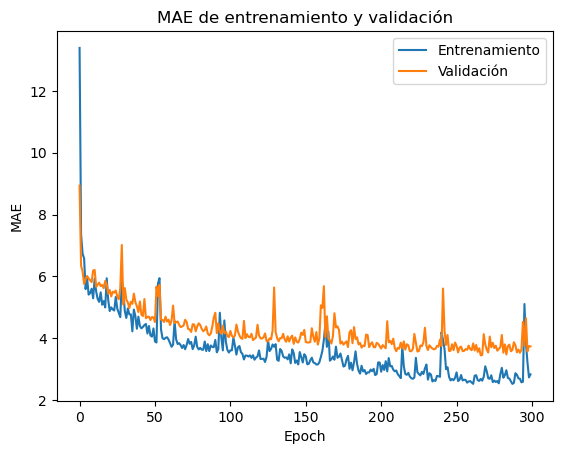

In [48]:
# Vamos a evaluar el modelo
resultado2 = model2.evaluate(test_data, test_targets, verbose=1)
print('Resultados del modelo')
print('Pérdida: ', resultado2[0])
print('MAE: ', resultado2[1])

# Representamos los resultados en una gráfica
print('Gráfica de evolución del entrenamiento')
plt.plot(history2.history['mae'])
plt.plot(history2.history['val_mae'])
plt.title('MAE de entrenamiento y validación')
plt.ylabel('MAE')
plt.xlabel('Epoch')
plt.legend(['Entrenamiento', 'Validación'], loc='upper right')
plt.show()

## <font color="#004D7F" size=4>Ejercicio 4</font>
Crear una red con la siguiente configuración y entrénala:

- **Configuración de la red**:
    - Arquitectura de la red:
        - *1º Capa*: capa de entrada donde indiques la dimensión de los datos.
        - *2º Capa*: capa densa con 32 neuronas y función de activación *relu*.
        - *3º Capa*: capa densa con 64 neuronas y función de activación *relu*.
        - *4º Capa*: capa densa con 128 neuronas y función de activación *relu*.
        - *4º Capa*: capa de salida con una neurona sin función de activación.   
    - Tipo de entrenamiento:
        - *Epochs*: 2OO
        - *Optimizador*: *adam*
        - *Learning Rate*: 0.001
        - *Función de error*: error cuadrático medio (*mean_squared_error*)

In [52]:
# Establecemos la arquitectura del modelo

model3 = tf.keras.Sequential()
model3.add(InputLayer(input_shape=(train_data.shape[1],)))
model3.add(Dense(32, activation='relu'))
model3.add(Dense(64, activation='relu'))
model3.add(Dense(128, activation='relu'))
model3.add(Dense(1, activation=None))

print(model3.summary())

Model: "sequential_13"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_31 (Dense)             (None, 32)                448       
_________________________________________________________________
dense_32 (Dense)             (None, 64)                2112      
_________________________________________________________________
dense_33 (Dense)             (None, 128)               8320      
_________________________________________________________________
dense_34 (Dense)             (None, 1)                 129       
Total params: 11,009
Trainable params: 11,009
Non-trainable params: 0
_________________________________________________________________
None


In [53]:
# Definimos el optimizador
opt = tf.keras.optimizers.Adam(learning_rate=0.001)

# Entrenamos el modelo
model3.compile(optimizer='adam', loss='mse', metrics=['mae'])
history3 = model3.fit(train_data, train_targets, validation_split=0.2, epochs=300, batch_size=32, verbose=1)

Epoch 1/300
11/11 [==============================] - 0s 5ms/step - loss: 741.6107 - mae: 22.1172 - val_loss: 364.7565 - val_mae: 14.4503
Epoch 2/300
11/11 [==============================] - 0s 778us/step - loss: 209.1679 - mae: 10.5268 - val_loss: 156.8651 - val_mae: 9.4283
Epoch 3/300
11/11 [==============================] - 0s 851us/step - loss: 100.1960 - mae: 7.3851 - val_loss: 77.2015 - val_mae: 6.8404
Epoch 4/300
11/11 [==============================] - 0s 858us/step - loss: 95.6325 - mae: 7.9960 - val_loss: 77.1837 - val_mae: 5.5623
Epoch 5/300
11/11 [==============================] - 0s 790us/step - loss: 66.5244 - mae: 5.5287 - val_loss: 72.1159 - val_mae: 5.5264
Epoch 6/300
11/11 [==============================] - 0s 773us/step - loss: 58.9041 - mae: 5.2810 - val_loss: 71.6203 - val_mae: 5.4840
Epoch 7/300
11/11 [==============================] - 0s 858us/step - loss: 58.3341 - mae: 5.2554 - val_loss: 71.0749 - val_mae: 5.4990
Epoch 8/300
11/11 [==============================

Evalúa el modelo usando la función *evaluate* para el conjunto de test:

4/4 [==============================] - 0s 429us/step - loss: 31.5224 - mae: 3.5468
Resultados del modelo
Pérdida:  29.036468505859375
MAE:  3.9004340171813965
Gráfica de evolución del entrenamiento


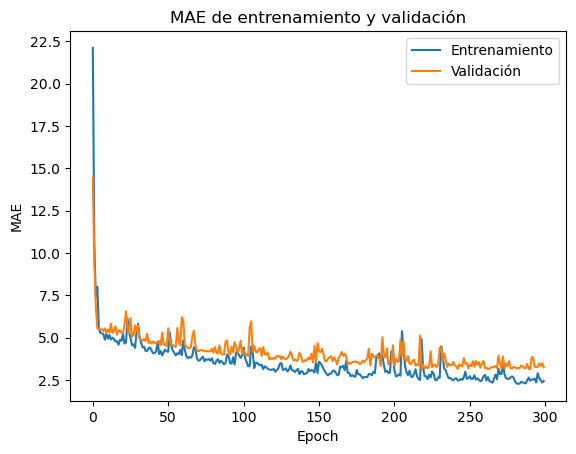

In [54]:
# Vamos a evaluar el modelo
resultado3 = model3.evaluate(test_data, test_targets, verbose=1)
print('Resultados del modelo')
print('Pérdida: ', resultado2[0])
print('MAE: ', resultado2[1])

# Representamos los resultados en una gráfica
print('Gráfica de evolución del entrenamiento')
plt.plot(history3.history['mae'])
plt.plot(history3.history['val_mae'])
plt.title('MAE de entrenamiento y validación')
plt.ylabel('MAE')
plt.xlabel('Epoch')
plt.legend(['Entrenamiento', 'Validación'], loc='upper right')
plt.show()

## <font color="#004D7F" size=4>Ejercicio 5</font>
Compara los resultados obtenidos en cada uno de los modelos entrenados y quédate con el mejor. **Justifica tu respuesta**.

El resultado no tiene porqué ser el mismo ya que los entrenamientos son aleatorios, pero un posible resultado podría ser este:

```
- Modelo 1: 83.3437 MSE
- Modelo 2: 51.6446 MSE
- Modelo 3: 27.6275 MSE
```

Además guarda el mejor modelo en formato *.h5* usando la función `save`:

In [ ]:
# Completar

## <font color="#004D7F" size=4>Ejercicio 6 (Opcional)</font>
Carga el mejor modelo que has guardado en el ejercicio anterior usando la función `load_model` y realizar predicciones usando la función `predict`.

Para realizar las predicciones usa 10 datos cualquier del conjunto de test:

In [ ]:
# Completar